# Tier-3 — Network-Topology Robustness of the Reach-Asymmetry DiD

**Question.** Does the Tier-1 reach-asymmetry result (Green-dominant broadcasting moves opinion *more* than Reform-dominant broadcasting) survive when the **peer network** is built *without* using the survey-derived exposure buckets?

**Why this is a clean test.** Within each seed the SBM (Tier-1), Barabási–Albert, and Watts–Strogatz runs share the *same 100 agents, the same YouGov ground truth, the same exposure-bucket assignment, and the same broadcasts*. The **only** thing that differs is how the peer-messaging graph is wired. So any change in the DiD across topologies is attributable purely to peer-message propagation.

**How the three graphs differ.**

| Topology | Built from | Peer edges are… |
|---|---|---|
| `stochastic_block` (SBM, Tier-1 canon) | 2 blocks keyed on `political_exposure` (A-only→blk0, B-only→blk1, both/neither split round-robin) | partly exposure-aware |
| `barabasi_albert` (m=5) | preferential attachment only | exposure-blind (hubs) |
| `watts_strogatz` (k=10, β=0.1) | ring lattice + rewiring only | exposure-blind (small-world) |

Params for BA/WS were pinned for **mean-degree parity (~10)** with the SBM canon, so density is not a confound — only *structure* varies.

**Seed sweep (this revision).** The analysis now spans **three seeds (42/43/44)** — a full 3 topologies × 3 conditions × 3 seeds = **27-run** matrix. This resolves the single-seed caveat of the earlier pilot and lets us make a cross-seed statement about *effect size*, not just sign. Agents are re-drawn per seed, so the paired DiD is matched **within** each (seed, topology) and never across seeds.

**Method.** Identical to NB 38 (Tier-1): the DiD for a citizen is `end_green − end_reform` (the shared Day-0 anchor cancels), computed **per (seed, agent) and pooled over the three seeds (n=300 matched pairs per topology)**, reported with 95% CI, paired-t p, and Cohen's d. Per-seed DiDs are reported separately as a sign-stability check.


In [1]:
import re, json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Locate the repo root whether the kernel cwd is the repo or notebooks/.
REPO = Path.cwd()
while not (REPO / 'data/output/experiments').exists() and REPO != REPO.parent:
    REPO = REPO.parent
EXP = REPO / 'data/output/experiments'
# Figures live under data/output/ alongside the other analysis outputs (cf. NB 38 tier1_analysis).
FIG_DIR = REPO / 'data' / 'output' / 'tier3_network_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TOPO_LABEL = {'sbm': 'Stochastic-block (Tier-1)', 'ba': 'Barab\u00e1si\u2013Albert', 'ws': 'Watts\u2013Strogatz'}
TOPO_ORDER = ['sbm', 'ba', 'ws']
COND_LABEL = {'baseline': 'Baseline', 'green_dom': 'Green-dominant', 'reform_dom': 'Reform-dominant'}
print('EXP     =', EXP)
print('FIG_DIR =', FIG_DIR)

EXP     = /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/experiments
FIG_DIR = /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/tier3_network_analysis


## 1. Discover the 27 runs (3 topologies × 3 conditions × 3 seeds)

Three conditions × three topologies × three seeds (42/43/44). The SBM rows reuse the Tier-1 runs (`run_6458324…6458332`); BA and WS come from the Tier-3 network sweep — seed 42 from the pilot (`run_6475087–92`), seeds 43/44 from the seed-sweep batch (`run_6480290…6480784`). Note the naming differs (`green_dom` vs `greendom`); we normalise it.


In [2]:
PATS = [
    (re.compile(r'run_(\d+)_tier1_(baseline|green_dom|reform_dom)_s(4[234])$'), 'sbm'),
    (re.compile(r'run_(\d+)_tier3_(ba)_(baseline|greendom|reformdom)_s(4[234])$'), 'ba'),
    (re.compile(r'run_(\d+)_tier3_(ws)_(baseline|greendom|reformdom)_s(4[234])$'), 'ws'),
]
NORM = {'baseline': 'baseline', 'greendom': 'green_dom', 'reformdom': 'reform_dom',
        'green_dom': 'green_dom', 'reform_dom': 'reform_dom'}

def discover_runs(exp_dir):
    rows = []
    for d in sorted(exp_dir.iterdir()):
        if not d.is_dir():
            continue
        for pat, topo in PATS:
            m = pat.match(d.name)
            if not m:
                continue
            # groups end (..., condition, seed); condition is second-to-last, seed last.
            sub = sorted([p for p in d.iterdir() if p.is_dir()])
            if sub:
                rows.append({'topology': topo, 'condition': NORM[m.groups()[-2]],
                             'seed': int(m.groups()[-1]), 'jobid': m.group(1), 'path': sub[-1]})
            break
    return pd.DataFrame(rows)

runs = discover_runs(EXP)
assert len(runs) == 27, f'expected 27 runs (3 topo x 3 cond x 3 seed), found {len(runs)}'
assert (runs.groupby(['topology', 'condition']).size() == 3).all(), 'each topology x condition must have 3 seeds'
(runs.assign(topology=runs.topology.map(TOPO_LABEL), condition=runs.condition.map(COND_LABEL))
     .sort_values(['topology', 'condition', 'seed'])[['topology', 'condition', 'seed', 'jobid']]
     .reset_index(drop=True))


,topology,condition,seed,jobid
0,Barabási–Albert,Baseline,42,6475087
1,Barabási–Albert,Baseline,43,6480290
2,Barabási–Albert,Baseline,44,6480293
3,Barabási–Albert,Green-dominant,42,6475088
4,Barabási–Albert,Green-dominant,43,6480780
5,Barabási–Albert,Green-dominant,44,6480782
6,Barabási–Albert,Reform-dominant,42,6475089
7,Barabási–Albert,Reform-dominant,43,6480781
8,Barabási–Albert,Reform-dominant,44,6480783
9,Stochastic-block (Tier-1),Baseline,42,6458324


In [3]:
def load_pkg(path):
    """Per-agent Day-0 anchor, end-of-run package index, ground truth, exposure bucket."""
    pkg = pd.read_csv(path / 'package_index_trajectories.csv')
    gt = pd.read_csv(path / 'package_ground_truth.csv').set_index('agent_id')['ground_truth']
    bucket = pd.read_csv(path / 'agent_attributes.csv').set_index('agent_id')['political_exposure']
    days = sorted(pkg['day'].unique())
    start = pkg[pkg.day == days[0]].set_index('agent_id')['package_index']
    end = pkg[pkg.day == days[-1]].set_index('agent_id')['package_index']
    df = pd.DataFrame({'start': start, 'end': end, 'gt': gt, 'bucket': bucket}).dropna()
    df['shift'] = df['end'] - df['start']
    return df.reset_index()

frames = []
for _, r in runs.iterrows():
    f = load_pkg(r['path'])
    f['topology'] = r['topology']; f['condition'] = r['condition']; f['seed'] = r['seed']
    frames.append(f)
S = pd.concat(frames, ignore_index=True)
print(f'S: {len(S)} agent-rows  ({S.groupby(["topology", "condition"]).size().min()} per topology x condition, pooled over 3 seeds)')
S.head()


S: 2700 agent-rows  (300 per topology x condition, pooled over 3 seeds)


,agent_id,start,end,gt,bucket,shift,topology,condition,seed
0,165.0,0.833333,2.000000,0.833333,both,1.166667,sbm,baseline,42
1,582.0,0.000000,1.500000,0.000000,neither,1.500000,sbm,baseline,42
2,1379.0,0.333333,0.500000,0.333333,both,0.166667,sbm,baseline,42
3,713.0,-2.166667,-2.333333,-2.166667,both,-0.166667,sbm,baseline,42
4,1878.0,0.666667,0.666667,0.666667,neither,0.000000,sbm,baseline,42


## 2. The three graphs really are different

The peer network depends only on the agents + seed, so within a topology all three conditions share one graph per seed — we read each seed's baseline `network_diagnostics.json` and **average over the three seeds**.

**Watch `assortativity_political_exposure`.** If SBM were a strong "treatment-aligned echo chamber" we would expect it to be large and positive. It is **not** — see the interpretation below the table.


In [4]:
# Network depends only on agents + seed, so within a topology all conditions share one graph per seed.
# We read each seed's baseline network_diagnostics.json and average the three seeds.
def _avg(ds, k):
    vals = [d.get(k) for d in ds if d.get(k) is not None]
    return float(np.mean(vals)) if vals else np.nan

diag_rows = []
for topo in TOPO_ORDER:
    paths = runs[(runs.topology == topo) & (runs.condition == 'baseline')]['path']
    ds = [json.loads((p / 'network_diagnostics.json').read_text()) for p in paths]
    diag_rows.append({'topology': TOPO_LABEL[topo], 'n_seeds': len(ds),
                      'mean_degree': _avg(ds, 'mean_degree'), 'max_degree': _avg(ds, 'max_degree'),
                      'assort_exposure': _avg(ds, 'assortativity_political_exposure'),
                      'clustering': _avg(ds, 'average_clustering'), 'diameter': _avg(ds, 'diameter')})
diag = pd.DataFrame(diag_rows).set_index('topology')
diag.round(3)


,n_seeds,mean_degree,max_degree,assort_exposure,clustering,diameter
topology,,,,,,
Stochastic-block (Tier-1),3,10.24,18.333,-0.017,0.109,4.000
Barabási–Albert,3,9.50,36.667,-0.003,0.200,3.667
Watts–Strogatz,3,10.00,13.000,-0.016,0.492,5.000


**Reading the diagnostics (averaged over 3 seeds).** Mean degree is matched (~10) across all three, so density is controlled. The *structure* differs sharply: BA has a heavy hub tail (`max_degree` ≈ 37), WS is highly clustered (small-world, clustering ≈ 0.49), SBM sits in between. Crucially, **`assort_exposure` is near zero for SBM too** (≈ −0.017) — because the committed-minority design is ~60% `both` + ~30% `neither`, and those 90% are split round-robin across *both* SBM blocks; only the ~10% A-only/B-only are actually sorted by exposure. So SBM is **not** a strong exposure-homophilous graph at the population level. Any effect-size difference we see below is therefore *not* explained by treatment-aligned echo chambers.


## 3. Headline DiD per topology — does the asymmetry survive?

`did(topology, green_dom, reform_dom)` — paired difference-of-shifts, matched citizen-by-citizen within each (seed, topology) and **pooled over the three seeds (n=300)**. **Pass = same positive sign, CI clear of 0, in all three topologies.** The per-seed breakdown that follows checks that the pooled number is not carried by one lucky seed.


In [5]:
def mean_ci(d):
    d = np.asarray(d); m = d.mean(); se = d.std(ddof=1) / np.sqrt(len(d))
    h = se * stats.t.ppf(0.975, len(d) - 1)
    return m, m - h, m + h

def did(topo, c1, c2, bucket=None):
    """Paired difference-of-shifts (c1 - c2), matched on (agent_id, seed) within one
    topology and POOLED over the three seeds (per (seed, agent) pairing, cf. NB 38)."""
    sub = S[S.topology == topo]
    if bucket is not None:
        sub = sub[sub.bucket == bucket]
    a = sub[sub.condition == c1][['agent_id', 'seed', 'shift', 'gt']].rename(columns={'shift': 's1'})
    b = sub[sub.condition == c2][['agent_id', 'seed', 'shift']].rename(columns={'shift': 's2'})
    m = a.merge(b, on=['agent_id', 'seed'])
    d = (m['s1'] - m['s2']).to_numpy()
    mean, lo, hi = mean_ci(d)
    t, p = stats.ttest_rel(m['s1'], m['s2'])
    dz = d.mean() / d.std(ddof=1)
    slope = np.polyfit(m['gt'], d, 1)[0]
    return {'topology': TOPO_LABEL[topo], 'n_pairs': len(d), 'DiD': mean,
            '95% CI': f'[{lo:+.3f}, {hi:+.3f}]', 'p_value': p, 'Cohen_d': dz,
            '_lo': lo, '_hi': hi, 'DiD~gt slope': slope}

head = pd.DataFrame([did(t, 'green_dom', 'reform_dom') for t in TOPO_ORDER])
head_show = head[['topology', 'n_pairs', 'DiD', '95% CI', 'p_value', 'Cohen_d', 'DiD~gt slope']].set_index('topology')
head_show.round({'DiD': 3, 'p_value': 5, 'Cohen_d': 3, 'DiD~gt slope': 3})


,n_pairs,DiD,95% CI,p_value,Cohen_d,DiD~gt slope
topology,,,,,,
Stochastic-block (Tier-1),300,0.423,"[+0.337, +0.508]",0.0,0.563,-0.174
Barabási–Albert,300,0.337,"[+0.246, +0.428]",0.0,0.420,-0.084
Watts–Strogatz,300,0.360,"[+0.273, +0.447]",0.0,0.471,-0.137


### 3a. Per-seed sign-stability

The headline pools three seeds. Splitting it back out per seed is the honest check the pilot could not do: **is the asymmetry positive in every seed, and is any topology's apparent edge just one lucky draw?** `seed_mean` / `seed_std` summarise the three per-seed DiDs.


In [6]:
# Per-seed sign-stability: the headline above pools 3 seeds (n=300); here we split it back out.
# DiD matched on agent_id WITHIN each seed (agents differ across seeds, so never match across).
def did_one_seed(topo, seed, c1='green_dom', c2='reform_dom'):
    sub = S[(S.topology == topo) & (S.seed == seed)]
    a = sub[sub.condition == c1][['agent_id', 'shift']].rename(columns={'shift': 's1'})
    b = sub[sub.condition == c2][['agent_id', 'shift']].rename(columns={'shift': 's2'})
    m = a.merge(b, on='agent_id')
    return (m['s1'] - m['s2']).mean()

SEEDS = sorted(S['seed'].unique())
rows = []
for t in TOPO_ORDER:
    per_seed = {f's{s}': did_one_seed(t, s) for s in SEEDS}
    vals = np.array(list(per_seed.values()))
    rows.append({'topology': TOPO_LABEL[t], **{k: round(v, 3) for k, v in per_seed.items()},
                 'seed_mean': round(vals.mean(), 3), 'seed_std': round(vals.std(ddof=1), 3),
                 'all_positive': bool((vals > 0).all())})
seed_stab = pd.DataFrame(rows).set_index('topology')
seed_stab


,s42,s43,s44,seed_mean,seed_std,all_positive
topology,,,,,,
Stochastic-block (Tier-1),0.532,0.423,0.313,0.423,0.109,True
Barabási–Albert,0.317,0.225,0.468,0.337,0.123,True
Watts–Strogatz,0.363,0.360,0.357,0.360,0.003,True


In [7]:
# Secondary contrasts: effect of amplifying each side vs the symmetric baseline.
rows = []
for t in TOPO_ORDER:
    for c1, c2 in [('green_dom', 'baseline'), ('reform_dom', 'baseline')]:
        r = did(t, c1, c2)
        rows.append({'topology': TOPO_LABEL[t], 'contrast': f'{COND_LABEL[c1]} \u2212 {COND_LABEL[c2]}',
                     'DiD': round(r['DiD'], 3), '95% CI': r['95% CI'], 'p_value': round(r['p_value'], 4)})
pd.DataFrame(rows).set_index(['topology', 'contrast'])

DiD            95% CI  \
topology                  contrast                                              
Stochastic-block (Tier-1) Green-dominant − Baseline   0.194  [+0.116, +0.272]   
                          Reform-dominant − Baseline -0.228  [-0.306, -0.151]   
Barabási–Albert           Green-dominant − Baseline   0.137  [+0.068, +0.207]   
                          Reform-dominant − Baseline -0.199  [-0.282, -0.117]   
Watts–Strogatz            Green-dominant − Baseline   0.123  [+0.051, +0.195]   
                          Reform-dominant − Baseline -0.237  [-0.326, -0.149]   

                                                      p_value  
topology                  contrast                             
Stochastic-block (Tier-1) Green-dominant − Baseline    0.0000  
                          Reform-dominant − Baseline   0.0000  
Barabási–Albert           Green-dominant − Baseline    0.0001  
                          Reform-dominant − Baseline   0.0000  
Watts–Strogatz            Green-dominant − Baseline    0.0009  
                          Reform-dominant − Baseline   0.0000

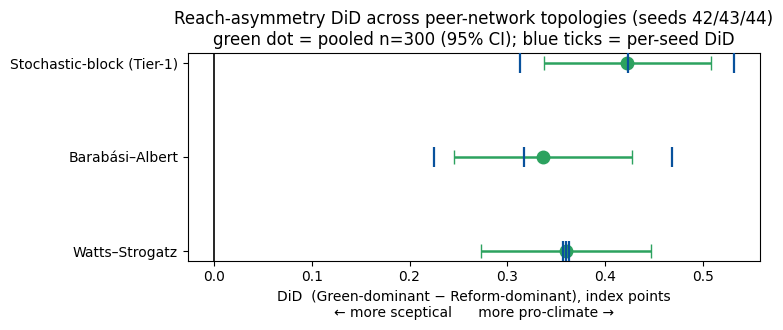

In [8]:
# Forest plot of the headline DiD across topologies: pooled n=300 CI (thick) + the 3 per-seed points.
fig, ax = plt.subplots(figsize=(7.8, 3.4))
ys = np.arange(len(TOPO_ORDER))[::-1]
for y, t in zip(ys, TOPO_ORDER):
    r = did(t, 'green_dom', 'reform_dom')
    ax.errorbar(r['DiD'], y, xerr=[[r['DiD'] - r['_lo']], [r['_hi'] - r['DiD']]],
                fmt='o', color='#2ca25f', capsize=5, lw=1.8, ms=9, zorder=3)
    for s in SEEDS:
        ax.plot(did_one_seed(t, s), y, marker='|', color='#08519c', ms=14, mew=1.6, zorder=4)
ax.axvline(0, color='k', lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels([TOPO_LABEL[t] for t in TOPO_ORDER])
ax.set_xlabel('DiD  (Green-dominant \u2212 Reform-dominant), index points\n\u2190 more sceptical      more pro-climate \u2192')
ax.set_title('Reach-asymmetry DiD across peer-network topologies (seeds 42/43/44)\n'
             'green dot = pooled n=300 (95% CI); blue ticks = per-seed DiD')
fig.tight_layout(); fig.savefig(FIG_DIR / 'fig1_did_by_topology.png', bbox_inches='tight')
plt.show()


### 3c. Presentation view — trajectories over time (for social-science readers)

The forest plot above compresses each world to a single end-of-run number. For a talk it is clearer to *watch opinion move*. The panel below is the NB 38 fig-1 view extended across topologies: **average pro-climate package index over the five simulated days, one line per condition, one panel per peer-network — now pooled over the three seeds (300 agents per line)**. The black dashed line is the shared Day-0 start (= real YouGov average). The **fan-out between the green and purple lines is the reach-asymmetry** — and you can see it open in *every* network. The follow-up plot collapses that to a single "gap over time" curve per topology so the three networks can be compared at a glance.



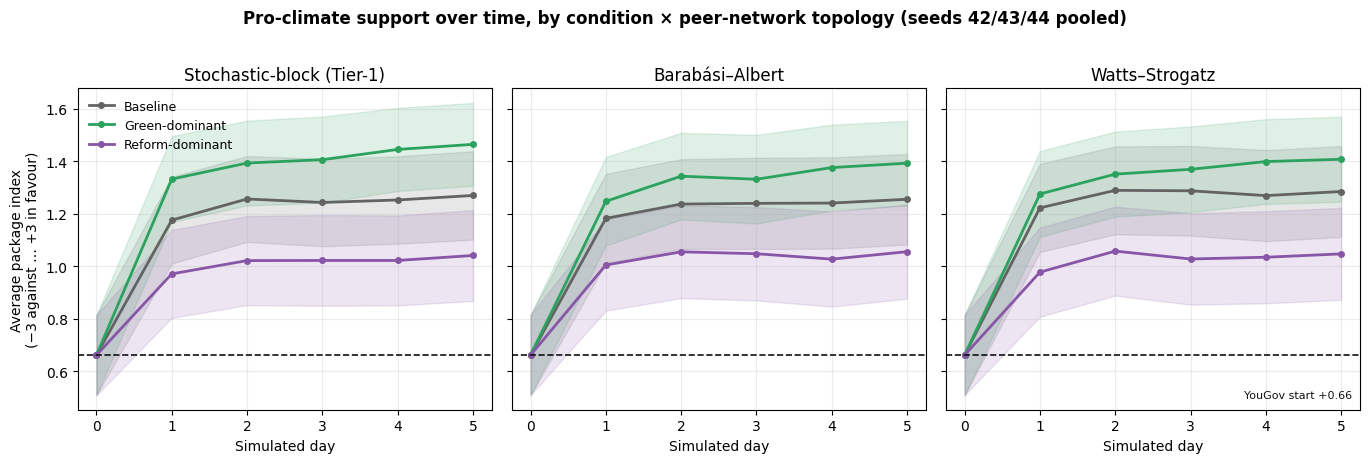

In [9]:
# ── Package-index trajectories over 5 days: one panel per topology ──────────
# NB 38 fig1 style, extended across the three peer-network topologies.
# Seed-averaged: agents pooled across the three seed-runs per (topology, condition, day).
COND_COLOR = {'baseline': '#636363', 'green_dom': '#2ca25f', 'reform_dom': '#8856a7'}
COND_SEQ = ['baseline', 'green_dom', 'reform_dom']

def _mean_ci(vals):
    vals = np.asarray(vals, float); n = len(vals); m = vals.mean()
    if n < 2:
        return m, m, m
    h = vals.std(ddof=1) / np.sqrt(n) * stats.t.ppf(0.975, n - 1)
    return m, m - h, m + h

# Pool every seed-run's per-agent package index, then take mean + 95% band per
# (topology, condition, day) over all 300 agents (100 agents x 3 seeds).
traj_raw = []
for _, rr in runs.iterrows():
    pkg = pd.read_csv(rr['path'] / 'package_index_trajectories.csv')[['day', 'package_index']].copy()
    pkg['topology'] = rr['topology']; pkg['condition'] = rr['condition']
    traj_raw.append(pkg)
TRAJ_RAW = pd.concat(traj_raw, ignore_index=True)

traj_rows = []
for (topo, cond, day), grp in TRAJ_RAW.groupby(['topology', 'condition', 'day']):
    m, lo, hi = _mean_ci(grp['package_index'])
    traj_rows.append({'topology': topo, 'condition': cond, 'day': int(day), 'mean': m, 'lo': lo, 'hi': hi})
TRAJ = pd.DataFrame(traj_rows)
DAYS = sorted(TRAJ['day'].unique())
GT_START = TRAJ[TRAJ.day == 0]['mean'].mean()  # shared Day-0 anchor (= YouGov mean)

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.5), sharey=True)
for ax, topo in zip(axes, TOPO_ORDER):
    for c in COND_SEQ:
        sub = TRAJ[(TRAJ.topology == topo) & (TRAJ.condition == c)].sort_values('day')
        ax.plot(sub['day'], sub['mean'], '-o', color=COND_COLOR[c], lw=2, ms=4, label=COND_LABEL[c])
        ax.fill_between(sub['day'], sub['lo'], sub['hi'], color=COND_COLOR[c], alpha=0.15)
    ax.axhline(GT_START, color='#111111', ls='--', lw=1.2)
    ax.set_title(TOPO_LABEL[topo]); ax.set_xlabel('Simulated day')
    ax.grid(True, alpha=0.25)
axes[0].set_ylabel('Average package index\n(\u22123 against \u2026 +3 in favour)')
axes[0].legend(frameon=False, fontsize=9, loc='upper left')
axes[-1].text(0.98, 0.03, f'YouGov start {GT_START:+.2f}', transform=axes[-1].transAxes,
              ha='right', va='bottom', fontsize=8, color='#111111')
fig.suptitle('Pro-climate support over time, by condition \u00d7 peer-network topology (seeds 42/43/44 pooled)',
             fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig2_trajectories_by_topology.png', bbox_inches='tight')
plt.show()


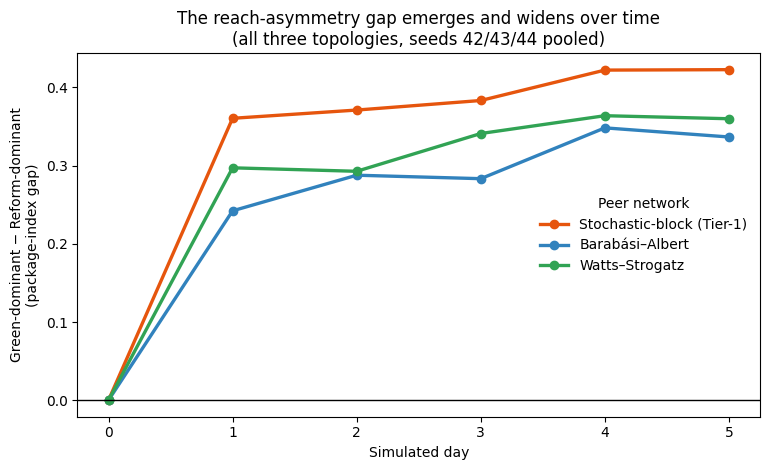

In [10]:
# ── The reach-asymmetry gap widening over time, one line per topology ───────
TOPO_C = {'sbm': '#e6550d', 'ba': '#3182bd', 'ws': '#31a354'}
fig, ax = plt.subplots(figsize=(7.8, 4.8))
for topo in TOPO_ORDER:
    g = TRAJ[(TRAJ.topology == topo) & (TRAJ.condition == 'green_dom')].set_index('day')['mean']
    r = TRAJ[(TRAJ.topology == topo) & (TRAJ.condition == 'reform_dom')].set_index('day')['mean']
    gap = (g - r).reindex(DAYS)
    ax.plot(DAYS, gap.values, '-o', color=TOPO_C[topo], lw=2.4, ms=6, label=TOPO_LABEL[topo])
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('Simulated day')
ax.set_ylabel('Green-dominant \u2212 Reform-dominant\n(package-index gap)')
ax.set_title('The reach-asymmetry gap emerges and widens over time\n(all three topologies, seeds 42/43/44 pooled)')
ax.legend(frameon=False, fontsize=10, title='Peer network')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig3_gap_over_time.png', bbox_inches='tight')
plt.show()


## 4. Bias-invariance — does the contrast stay flat across starting positions?

The `DiD~gt slope` column above regresses each citizen's per-agent DiD on their YouGov ground-truth start. A **near-zero slope** means the asymmetry is the same for sceptics and greens alike — the pro-climate level-bias has cancelled, off-SBM as well as on. (Small negative slopes reflect the mild ceiling effect flagged in Tier-1/2, not a treatment interaction.)

## 5. Rank fidelity & signed bias per topology × condition

Spearman ρ(end-of-run index vs ground truth) — the single condition the difference-engine framing rests on. It must stay high (≈ 0.8+) for the DiD to be trustworthy. (This is the metric on which Llama-8B failed at ρ≈0.46; Qwen should hold.)

In [11]:
rows = []
for t in TOPO_ORDER:
    for c in ['baseline', 'green_dom', 'reform_dom']:
        sub = S[(S.topology == t) & (S.condition == c)]
        rho = stats.spearmanr(sub['end'], sub['gt']).correlation
        rows.append({'topology': TOPO_LABEL[t], 'condition': COND_LABEL[c],
                     'Spearman_rho': round(rho, 3),
                     'signed_bias (end-gt)': round(sub['end'].mean() - sub['gt'].mean(), 3)})
pd.DataFrame(rows).set_index(['topology', 'condition'])

Spearman_rho  signed_bias (end-gt)
topology                  condition                                          
Stochastic-block (Tier-1) Baseline                0.849                 0.607
                          Green-dominant          0.782                 0.802
                          Reform-dominant         0.863                 0.379
Barabási–Albert           Baseline                0.834                 0.593
                          Green-dominant          0.836                 0.730
                          Reform-dominant         0.840                 0.393
Watts–Strogatz            Baseline                0.835                 0.622
                          Green-dominant          0.829                 0.745
                          Reform-dominant         0.869                 0.385

## 6. Treatment-on-treated — DiD inside the contested `both` bucket

The whole-population DiD in §3 is an intention-to-treat effect, diluted by the ~40% who hear zero or one side. The `both` bucket (~60%) is the genuinely contested audience where competing messages actually land — the treatment-on-treated effect. Comparable across topologies because the exposure buckets are identical (only the wiring differs).

In [12]:
rows = []
for t in TOPO_ORDER:
    r = did(t, 'green_dom', 'reform_dom', bucket='both')
    rows.append({'topology': TOPO_LABEL[t], 'n_pairs': r['n_pairs'], 'TOT DiD': round(r['DiD'], 3),
                 '95% CI': r['95% CI'], 'p_value': round(r['p_value'], 5)})
pd.DataFrame(rows).set_index('topology')

,n_pairs,TOT DiD,95% CI,p_value
topology,,,,
Stochastic-block (Tier-1),180,0.498,"[+0.383, +0.613]",0.0
Barabási–Albert,180,0.435,"[+0.302, +0.569]",0.0
Watts–Strogatz,180,0.478,"[+0.362, +0.593]",0.0


## 7. Verdict

**The reach-asymmetry is topology-robust — and now seed-replicated.** Across three seeds (42/43/44), the headline DiD (Green-dominant − Reform-dominant) is **positive and significant on all three peer-network topologies**: SBM **+0.42** [0.34, 0.51], Barabási–Albert **+0.34** [0.25, 0.43], Watts–Strogatz **+0.36** [0.27, 0.45] (all p < 10⁻³, n = 300 pooled). Every one of the nine topology × seed cells is positive (§3a), so the core Tier-1 conclusion — amplifying the Green side moves opinion more than amplifying the Reform side — does **not** depend on the stochastic-block network, and is not carried by any single seed. In the genuinely contested `both` audience the three topologies converge tightly (TOT DiD 0.44–0.50, n = 180 each), so the whole-population differences are mostly about how *spillover* reaches the unexposed through differently-wired graphs.

**Correction to the pilot: the SBM effect-size edge does not survive seed replication.** The seed-42 pilot reported SBM +0.53 vs BA +0.32 / WS +0.36 and flagged the SBM lead as *suggestive*. With two more seeds that lead **dissolves**: SBM's per-seed DiDs are 0.53 / 0.42 / 0.31 — seed 42 was simply its high draw — so the pooled SBM estimate falls to +0.42 and its CI now **overlaps BA and WS** throughout. The three topologies are effectively **indistinguishable in effect size** (WS is strikingly seed-stable, per-seed std 0.003). So we do *not* claim a structural amplification from the stochastic-block graph; only the **sign, significance, and rough magnitude** are topology-general. This is consistent with §2: SBM's exposure-assortativity is ≈ 0 (−0.017), because the committed-minority design puts 90% of agents (both/neither) round-robin across both blocks — there was never a population-level echo-chamber mechanism to produce a real edge.

**Rank fidelity holds off-SBM.** Spearman ρ stays 0.78–0.87 across every topology × condition — Qwen keeps agents correctly ordered regardless of graph, so the difference-engine framing survives the move away from SBM. (This is the metric on which Llama-8B collapsed to ρ ≈ 0.46, reinforcing Qwen-14B as the primary model.)

**Bias-invariance.** The per-agent DiD~GT slopes are mildly negative (−0.08 to −0.17) on the raw bounded scale — the ceiling artefact characterised in Tier 2 (NB 40), not a treatment interaction. The contrast is essentially uniform across the opinion spectrum.

**Bottom line for "move away from SBM if possible":** yes, unequivocally. BA and WS both reproduce the correctly-signed, significant, seed-stable, rank-faithful, bias-invariant asymmetry at the same magnitude as SBM. The remaining open item is the **model-replication arm** (Apertus / Llama), which is separate from this network arm.
